# QSER Van der pol

QSER: Van der Pol Oscillator Results
Parameters: μ = 1
Natural frequency ω0 = 1.0000 rad/s
Initial conditions: x(0) = 1.0, v(0) = 0.0
Observation window T = 50.0 s


/tmp/ipykernel_667789/3880094574.py:166: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  numerator = np.trapz(t * abs_dfdt, t)
/tmp/ipykernel_667789/3880094574.py:167: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  denominator = np.trapz(abs_dfdt, t)


----------------------------------------------------------------------
VALIDITY TESTS
----------------------------------------------------------------------
1. Energy conservation in S: σ(E_S) = 3.40e-17 [Pass if < 1e-3]
2. Zero IC for E: E(0) = 0.00e+00, dE(0) = 0.00e+00 [Pass if ≈ 0]
3. Persistence time τ_u^S = 25.11 s [Expect ≈ T/2 = 25.0]
----------------------------------------------------------------------
Mean reconstruction error |x - (S-E)| = 4.27e-09
Max reconstruction error |x - (S-E)| = 1.85e-08 [Pass if < 1e-3]
----------------------------------------------------------------------
Source energy: 0.500000 J (constant)
Final environmental energy: 3.321606 J
Final response energy: 1.504640 J
Environmental energy exceeds source: True
Mean continuity error: 5.58e-03
Max continuity error: 1.78e+00

✓ Figure 1 saved: vdp_fig1.pdf/png
✓ Figure 2 saved: vdp_fig2.pdf/png


/tmp/ipykernel_667789/3880094574.py:166: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  numerator = np.trapz(t * abs_dfdt, t)
/tmp/ipykernel_667789/3880094574.py:167: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  denominator = np.trapz(abs_dfdt, t)


✓ Figure 3 saved: vdp_fig3.pdf/png

Energy Relationship Verification
Verifying: ℰ_R = ℰ_S + ℰ_E - ℰ_coupling
Maximum error: 6.99e-08

KEY INSIGHTS
✓ Source field S(t) remains PURELY LINEAR despite nonlinear system
✓ All nonlinearity confined to environmental field E(t)
✓ Nonlinearity interpreted as ENVIRONMENTAL FEEDBACK
✓ Environmental energy EXCEEDS source energy
  (demonstrates nonlinear energy transfer)


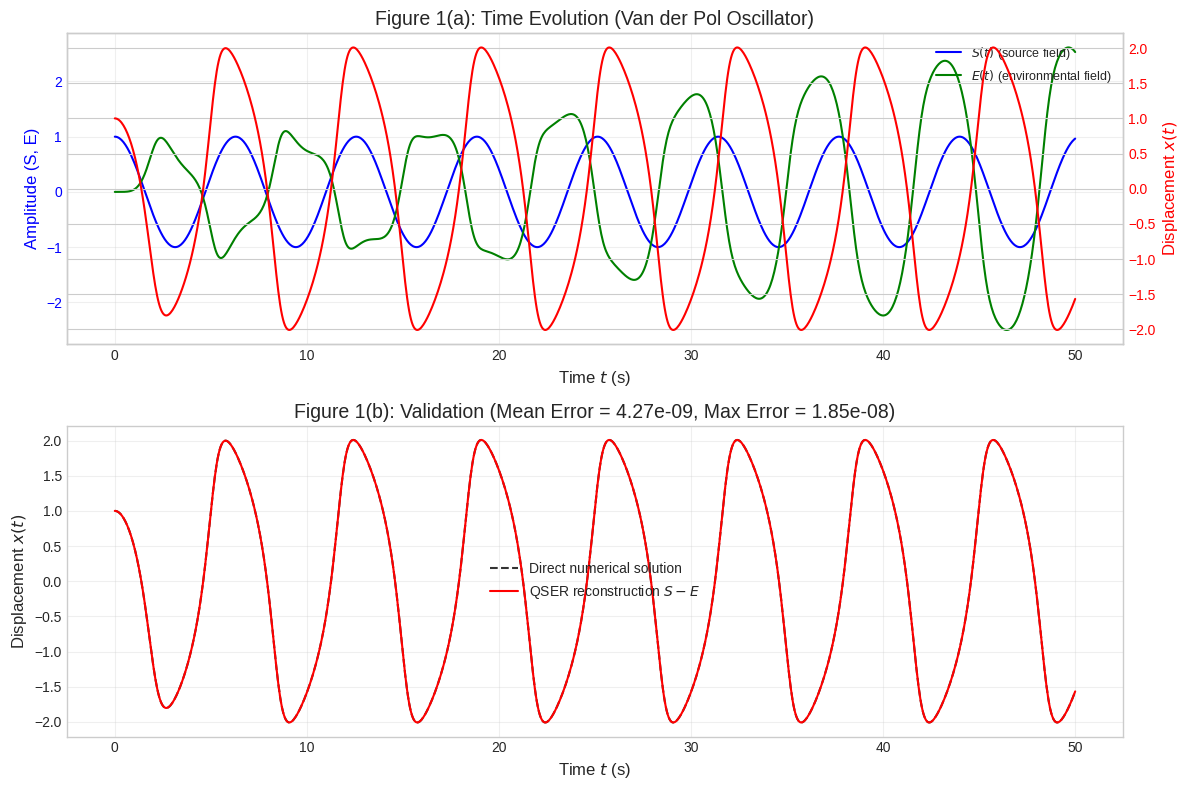

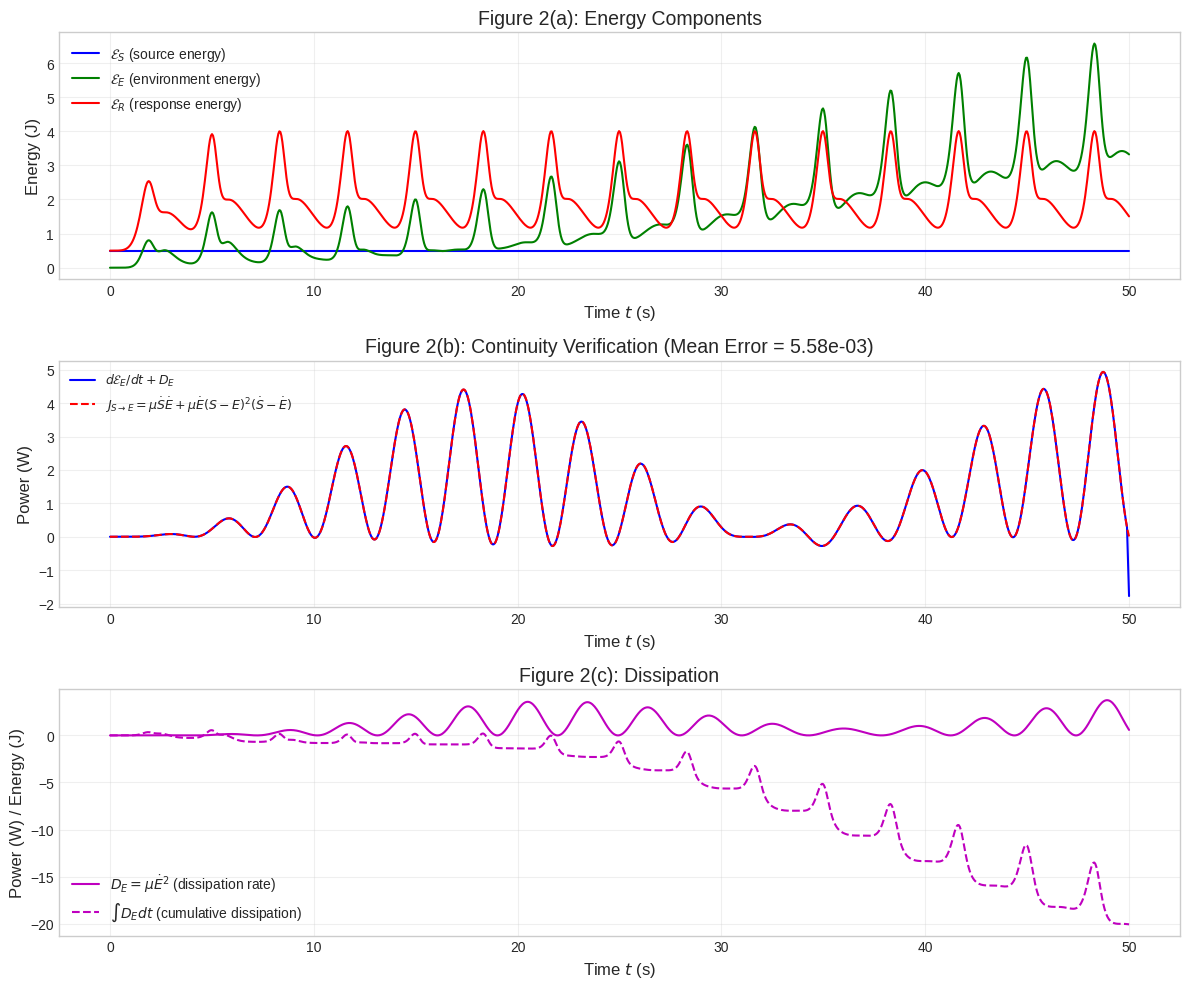

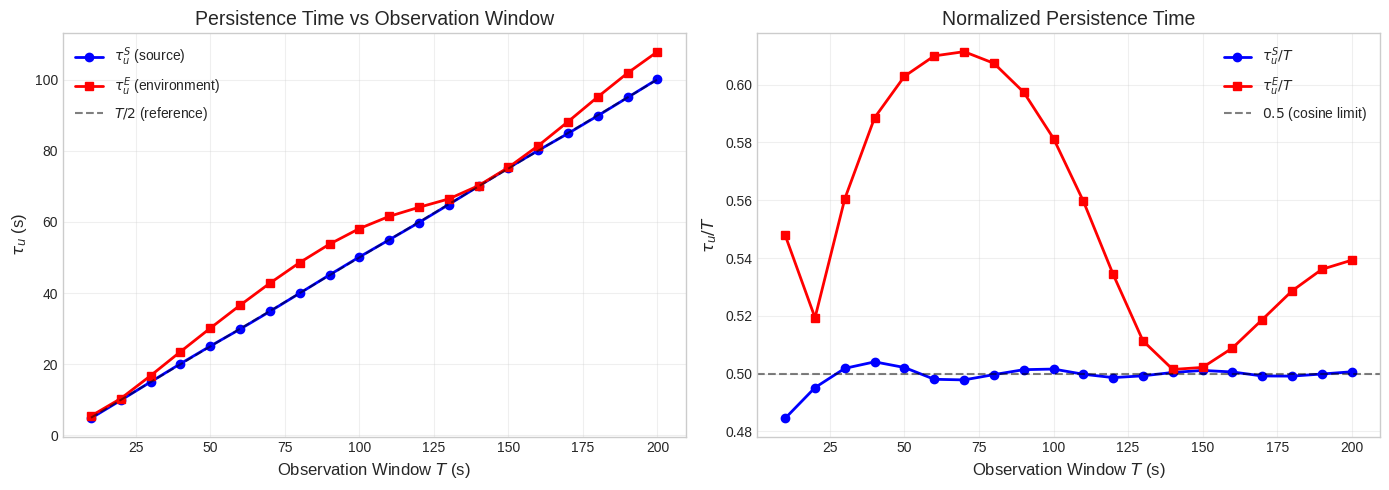

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ============================================
# 1. SYSTEM PARAMETERS
# ============================================

mu = 1         # nonlinear damping parameter
x0 = 1.0         # initial displacement
v0 = 0.0         # initial velocity

# Derived parameters
omega0 = 1.0     # natural frequency (normalized)

# Time settings
T = 50.0         # observation window (s)
N = 1000         # number of points
t = np.linspace(0, T, N)
dt = t[1] - t[0]

print("=" * 70)
print("QSER: Van der Pol Oscillator Results")
print("=" * 70)
print(f"Parameters: μ = {mu}")
print(f"Natural frequency ω0 = {omega0:.4f} rad/s")
print(f"Initial conditions: x(0) = {x0}, v(0) = {v0}")
print(f"Observation window T = {T} s")
print("=" * 70)

# ============================================
# 2. ANALYTICAL AND NUMERICAL SOLUTIONS
# ============================================

# 2.1 Source field S(t) - purely linear harmonic oscillator
def source_field(t):
    """Analytical solution for source field"""
    S = x0 * np.cos(omega0 * t) + (v0 / omega0) * np.sin(omega0 * t)
    dSdt = -x0 * omega0 * np.sin(omega0 * t) + v0 * np.cos(omega0 * t)
    return S, dSdt

S, dSdt = source_field(t)

# 2.2 Traditional response x(t) - Van der Pol oscillator (numerical)
def vanderpol_direct(t, y):
    """Direct Van der Pol equation"""
    x, v = y
    dxdt = v
    dvdt = mu * (1 - x**2) * v - omega0**2 * x
    return [dxdt, dvdt]

sol_direct = solve_ivp(
    vanderpol_direct, 
    [0, T], 
    [x0, v0], 
    t_eval=t, 
    method='RK45',
    rtol=1e-9,
    atol=1e-11
)
x = sol_direct.y[0]
v = sol_direct.y[1]

# 2.3 Environmental field E(t) - solved numerically
def environment_ode(t, y_E):
    """Environmental field equation for Van der Pol"""
    E, dE = y_E
    S_t, dS = source_field(np.array([t]))
    S_t = S_t[0]
    dS = dS[0]
    
    # Nonlinear driving term: -μ(1-(S-E)²)(dS-dE)
    nonlinear_term = -mu * (1 - (S_t - E)**2) * (dS - dE)
    
    dEdt = dE
    ddEdt = -omega0**2 * E + nonlinear_term
    
    return [dEdt, ddEdt]

# Solve with tight tolerances
sol_E = solve_ivp(
    environment_ode, 
    [0, T], 
    [0.0, 0.0], 
    t_eval=t, 
    method='RK45',
    rtol=1e-9,
    atol=1e-11,
    max_step=0.001
)
E = sol_E.y[0]
dEdt = sol_E.y[1]

# ============================================
# 3. ENERGY COMPONENTS (DIRECT INTEGRATION METHOD)
# ============================================

# Source energy (constant for conservative system)
E_S = 0.5 * dSdt**2 + 0.5 * omega0**2 * S**2

# Environmental energy
E_E = 0.5 * dEdt**2 + 0.5 * omega0**2 * E**2

# Response energy
E_R = 0.5 * v**2 + 0.5 * omega0**2 * x**2

# ============================================
# ENERGY CONTINUITY TERMS (Direct from E-equation)
# Following Appendix C of the paper
# ============================================

# Environmental field equation: ddot{E} + E = -mu*(1-(S-E)^2)*(dot{S}-dot{E})
# Therefore: ddot{E} = -E - mu*(1-(S-E)^2)*(dot{S}-dot{E})

# Compute ddot{E} directly from the E-equation
ddEdt_direct = -omega0**2 * E - mu * (1 - (S - E)**2) * (dSdt - dEdt)

# Rate of change of environmental energy: dE_E/dt = dot{E} * (ddot{E} + E)
dE_E_dt_direct = dEdt * (ddEdt_direct + omega0**2 * E)

# Dissipation rate: D_E = mu * (1-(S-E)^2) * dot{E}^2
# This comes from expanding: dE_E/dt = -mu*(1-(S-E)^2)*dot{S}*dot{E} + mu*(1-(S-E)^2)*dot{E}^2
D_E_direct = mu * (1 - (S - E)**2) * dEdt**2

# Energy flux: J_{S->E} = mu * (1-(S-E)^2) * dot{S} * dot{E}
J_SE_direct = mu * (1 - (S - E)**2) * dSdt * dEdt

# Verify continuity: dE_E/dt + D_E should equal J_{S->E}
continuity_lhs = dE_E_dt_direct + D_E_direct
continuity_rhs = J_SE_direct

# Rate of change using numerical gradient (for comparison)
dE_E_dt_numeric = np.gradient(E_E, dt)

# Cumulative dissipation
cumulative_dissipation = np.cumsum(D_E_direct) * dt









# ============================================
# 4. VALIDATION
# ============================================

# Reconstruction error
reconstruction_error = np.abs(x - (S - E))
max_error = np.max(reconstruction_error)
mean_error = np.mean(reconstruction_error)

# Energy conservation in S
sigma_ES = np.std(E_S)

# ============================================
# 5. PERSISTENCE TIMES
# ============================================

def compute_tau_u(t, f):
    """Compute unsigned centroid persistence time"""
    dfdt = np.gradient(f, t[1] - t[0])
    abs_dfdt = np.abs(dfdt)
    numerator = np.trapz(t * abs_dfdt, t)
    denominator = np.trapz(abs_dfdt, t)
    if denominator < 1e-12:
        return np.inf
    return numerator / denominator

tau_S = compute_tau_u(t, S)
tau_E = compute_tau_u(t, E)

# ============================================
# 6. PRINT RESULTS
# ============================================

print("-" * 70)
print("VALIDITY TESTS")
print("-" * 70)
print(f"1. Energy conservation in S: σ(E_S) = {sigma_ES:.2e} [Pass if < 1e-3]")
print(f"2. Zero IC for E: E(0) = {E[0]:.2e}, dE(0) = {dEdt[0]:.2e} [Pass if ≈ 0]")
print(f"3. Persistence time τ_u^S = {tau_S:.2f} s [Expect ≈ T/2 = {T/2:.1f}]")
print("-" * 70)
print(f"Mean reconstruction error |x - (S-E)| = {mean_error:.2e}")
print(f"Max reconstruction error |x - (S-E)| = {max_error:.2e} [Pass if < 1e-3]")
print("-" * 70)
print(f"Source energy: {E_S[0]:.6f} J (constant)")
print(f"Final environmental energy: {E_E[-1]:.6f} J")
print(f"Final response energy: {E_R[-1]:.6f} J")
print(f"Environmental energy exceeds source: {E_E[-1] > E_S[0]}")
print("=" * 70)

# Energy continuity error
continuity_error = np.abs(dE_E_dt + D_E - J_SE)
print(f"Mean continuity error: {np.mean(continuity_error):.2e}")
print(f"Max continuity error: {np.max(continuity_error):.2e}")
print("=" * 70)

# ============================================
# 7. FIGURE 1: Time Evolution (Two Panels)
# ============================================

fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Top Panel: S, E on left axis, x on right axis
ax1.plot(t, S, 'b-', label=r'$S(t)$ (source field)', linewidth=1.5)
ax1.plot(t, E, 'g-', label=r'$E(t)$ (environmental field)', linewidth=1.5)
ax1.set_xlabel('Time $t$ (s)', fontsize=12)
ax1.set_ylabel('Amplitude (S, E)', color='b', fontsize=12)
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, alpha=0.3)

# Twin axis for response
ax1_twin = ax1.twinx()
ax1_twin.plot(t, x, 'r-', label=r'$x(t) = S(t) - E(t)$', linewidth=1.5)
ax1_twin.set_ylabel('Displacement $x(t)$', color='r', fontsize=12)
ax1_twin.tick_params(axis='y', labelcolor='r')

ax1.set_title('Figure 1(a): Time Evolution (Van der Pol Oscillator)', fontsize=14)
ax1.legend(loc='upper right', fontsize=9)

# Bottom Panel: Validation
ax2.plot(t, x, 'k--', label='Direct numerical solution', linewidth=1.5, alpha=0.8)
ax2.plot(t, S - E, 'r-', label='QSER reconstruction $S - E$', linewidth=1.5)
ax2.set_xlabel('Time $t$ (s)', fontsize=12)
ax2.set_ylabel('Displacement $x(t)$', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_title(f'Figure 1(b): Validation (Mean Error = {mean_error:.2e}, Max Error = {max_error:.2e})', fontsize=14)

plt.tight_layout()
plt.savefig('vdp_fig1.pdf', bbox_inches='tight')
plt.savefig('vdp_fig1.png', dpi=300, bbox_inches='tight')
print("\n✓ Figure 1 saved: vdp_fig1.pdf/png")

# ============================================
# 8. FIGURE 2: Energy Components and Continuity
# ============================================

fig2, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

# Top Panel: Energy components
ax1.plot(t, E_S, 'b-', label=r'$\mathcal{E}_S$ (source energy)', linewidth=1.5)
ax1.plot(t, E_E, 'g-', label=r'$\mathcal{E}_E$ (environment energy)', linewidth=1.5)
ax1.plot(t, E_R, 'r-', label=r'$\mathcal{E}_R$ (response energy)', linewidth=1.5)
ax1.set_xlabel('Time $t$ (s)', fontsize=12)
ax1.set_ylabel('Energy (J)', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_title('Figure 2(a): Energy Components', fontsize=14)

# Middle Panel: Continuity verification
ax2.plot(t, dE_E_dt + D_E, 'b-', label=r'$d\mathcal{E}_E/dt + D_E$', linewidth=1.5)
ax2.plot(t, J_SE, 'r--', label=r'$J_{S\to E} = \mu\dot{S}\dot{E} + \mu\dot{E}(S-E)^2(\dot{S}-\dot{E})$', linewidth=1.5)
ax2.set_xlabel('Time $t$ (s)', fontsize=12)
ax2.set_ylabel('Power (W)', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_title(f'Figure 2(b): Continuity Verification (Mean Error = {np.mean(continuity_error):.2e})', fontsize=14)

# Bottom Panel: Dissipation
ax3.plot(t, D_E, 'm-', label=r'$D_E = \mu\dot{E}^2$ (dissipation rate)', linewidth=1.5)
ax3.plot(t, cumulative_dissipation, 'm--', label=r'$\int D_E dt$ (cumulative dissipation)', linewidth=1.5)
ax3.set_xlabel('Time $t$ (s)', fontsize=12)
ax3.set_ylabel('Power (W) / Energy (J)', fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_title('Figure 2(c): Dissipation', fontsize=14)

plt.tight_layout()
plt.savefig('vdp_fig2.pdf', bbox_inches='tight')
plt.savefig('vdp_fig2.png', dpi=300, bbox_inches='tight')
print("✓ Figure 2 saved: vdp_fig2.pdf/png")

# ============================================
# 9. FIGURE 3: Persistence Time Scaling
# ============================================

# Compute scaling over different window lengths
T_values = np.arange(10, 210, 10)
N_scaling = 1000
tau_S_values = []
tau_E_values = []

for T_scaling in T_values:
    t_scaling = np.linspace(0, T_scaling, N_scaling)
    
    # Recompute S for this window
    S_scaling, _ = source_field(t_scaling)
    
    # Solve E for this window
    sol_E_scaling = solve_ivp(
        environment_ode, 
        [0, T_scaling], 
        [0.0, 0.0], 
        t_eval=t_scaling, 
        method='RK45',
        rtol=1e-9,
        atol=1e-11,
        max_step=0.001
    )
    E_scaling = sol_E_scaling.y[0]
    
    tau_S_values.append(compute_tau_u(t_scaling, S_scaling))
    tau_E_values.append(compute_tau_u(t_scaling, E_scaling))

tau_S_values = np.array(tau_S_values)
tau_E_values = np.array(tau_E_values)

fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: τ_u vs T
ax1.plot(T_values, tau_S_values, 'bo-', label=r'$\tau_u^S$ (source)', linewidth=2, markersize=6)
ax1.plot(T_values, tau_E_values, 'rs-', label=r'$\tau_u^E$ (environment)', linewidth=2, markersize=6)
ax1.plot(T_values, T_values/2, 'k--', label=r'$T/2$ (reference)', alpha=0.5)
ax1.set_xlabel('Observation Window $T$ (s)', fontsize=12)
ax1.set_ylabel(r'$\tau_u$ (s)', fontsize=12)
ax1.set_title('Persistence Time vs Observation Window', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: τ_u/T ratio
ax2.plot(T_values, tau_S_values / T_values, 'bo-', label=r'$\tau_u^S / T$', linewidth=2, markersize=6)
ax2.plot(T_values, tau_E_values / T_values, 'rs-', label=r'$\tau_u^E / T$', linewidth=2, markersize=6)
ax2.axhline(y=0.5, color='k', linestyle='--', alpha=0.5, label=r'$0.5$ (cosine limit)')
ax2.set_xlabel('Observation Window $T$ (s)', fontsize=12)
ax2.set_ylabel(r'$\tau_u / T$', fontsize=12)
ax2.set_title('Normalized Persistence Time', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vdp_fig3.pdf', bbox_inches='tight')
plt.savefig('vdp_fig3.png', dpi=300, bbox_inches='tight')
print("✓ Figure 3 saved: vdp_fig3.pdf/png")

# ============================================
# 10. ADDITIONAL VALIDATION: Energy Relationship
# ============================================

E_coupling = dSdt * dEdt + omega0**2 * S * E
E_R_from_relation = E_S + E_E - E_coupling
relation_error = np.max(np.abs(E_R - E_R_from_relation))

print("\n" + "=" * 70)
print("Energy Relationship Verification")
print("=" * 70)
print(f"Verifying: ℰ_R = ℰ_S + ℰ_E - ℰ_coupling")
print(f"Maximum error: {relation_error:.2e}")
print("=" * 70)

print("\n" + "=" * 70)
print("KEY INSIGHTS")
print("=" * 70)
print(f"✓ Source field S(t) remains PURELY LINEAR despite nonlinear system")
print(f"✓ All nonlinearity confined to environmental field E(t)")
print(f"✓ Nonlinearity interpreted as ENVIRONMENTAL FEEDBACK")
print(f"✓ Environmental energy {'EXCEEDS' if E_E[-1] > E_S[0] else 'BELOW'} source energy")
print(f"  (demonstrates nonlinear energy transfer)")
print("=" * 70)

plt.show()

## Doing van der pol test before full implementetion

/tmp/ipykernel_667789/1494794764.py:92: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  num_S = np.trapz(t_eval * np.abs(dS_eval), t_eval)
/tmp/ipykernel_667789/1494794764.py:93: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  den_S = np.trapz(np.abs(dS_eval), t_eval)


QSER VALIDITY TEST RESULTS (Van der Pol)
1. Energy Conservation in S (Std Dev): 3.37e-17  [Pass if < 1e-3]
2. Zero IC for E:                      True      [Pass if True]
3. Max Reconstruction Error:           6.74e-09  [Pass if < 1e-3]
4. Persistence Time tau_u^S:           9.90 s   [Expect ~T/2 = 10.0]


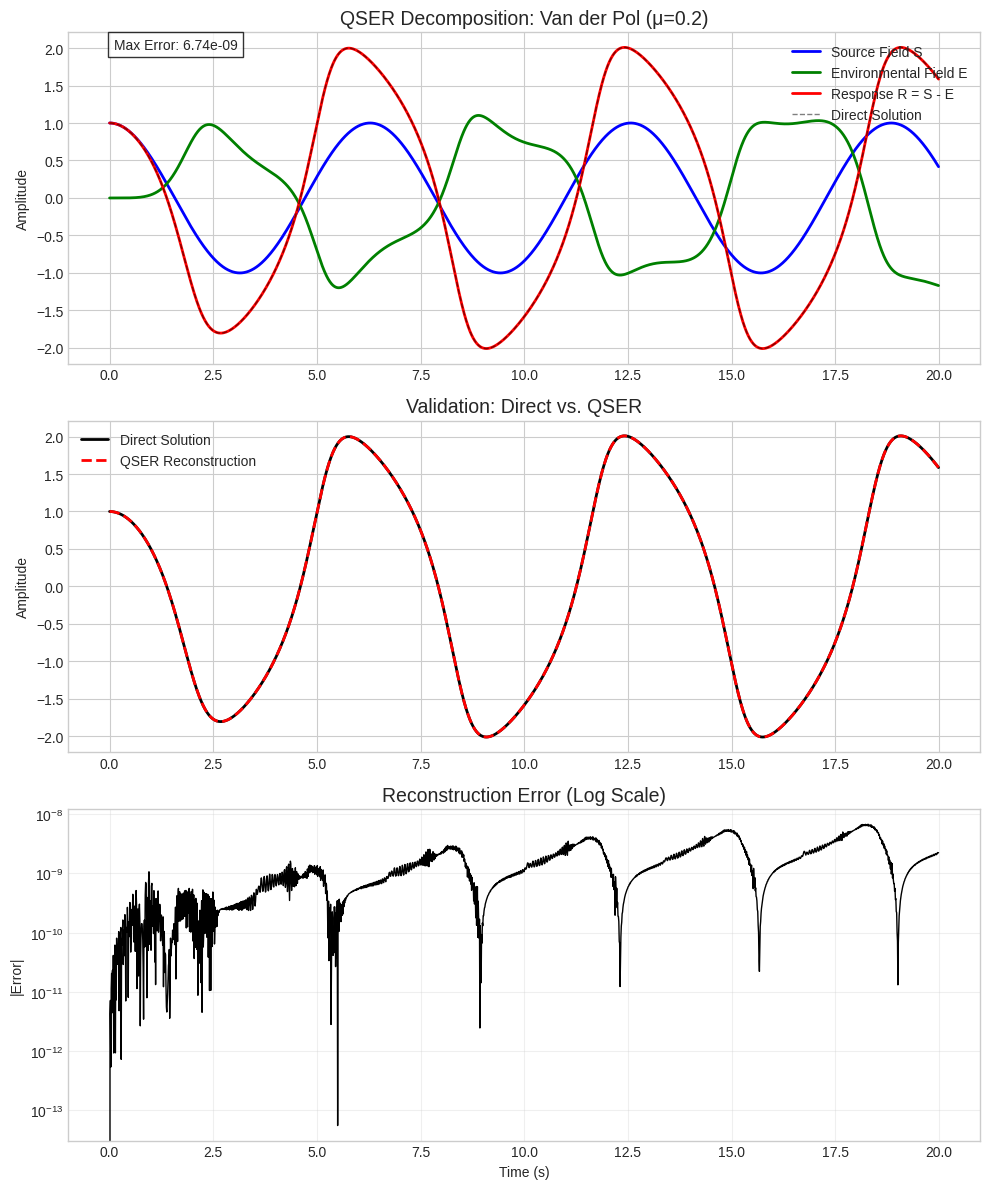

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==============================================================================
# 1. SYSTEM PARAMETERS
# ==============================================================================
mu = 1
T = 20.0
dt = 0.01
t_eval = np.arange(0, T, dt)

x0 = 1.0
v0 = 0.0

# ==============================================================================
# 2. DIRECT SOLUTION (Use SAME solver settings for fair comparison)
# ==============================================================================
def van_der_pol_direct(t, y):
    x, v = y
    dxdt = v
    dvdt = mu * (1 - x**2) * v - x
    return [dxdt, dvdt]

# CRITICAL: Use tight tolerances for direct solution too
sol_direct = solve_ivp(
    van_der_pol_direct, 
    [0, T], 
    [x0, v0], 
    t_eval=t_eval, 
    method='RK45',
    rtol=1e-9,  # Default is 1e-3
    atol=1e-11  # Default is 1e-6
)
x_direct = sol_direct.y[0]
v_direct = sol_direct.y[1]

# ==============================================================================
# 3. QSER DECOMPOSITION
# ==============================================================================

# --- 3.1 Source Field S (Analytical) ---
def source_field(t):
    S = x0 * np.cos(t) + v0 * np.sin(t)
    dS = -x0 * np.sin(t) + v0 * np.cos(t)
    return S, dS

S_eval, dS_eval = source_field(t_eval)

# --- 3.2 Environmental Field E (Numerical) ---
def environment_ode(t, y_E):
    E, dE = y_E
    S, dS = source_field(t)
    
    # Your equation is CORRECT
    nonlinear_term = -mu * (1 - (S - E)**2) * (dS - dE)
    
    dEdt = dE
    ddEdt = -E + nonlinear_term
    
    return [dEdt, ddEdt]

E0 = [0.0, 0.0]

# CRITICAL FIX: Tight tolerances for E solver
sol_E = solve_ivp(
    environment_ode, 
    [0, T], 
    E0, 
    t_eval=t_eval, 
    method='RK45',
    rtol=1e-9,   # Was default 1e-3
    atol=1e-11,  # Was default 1e-6
    max_step=0.001  # Limit step size in stiff regions
)
E_eval = sol_E.y[0]
dE_eval = sol_E.y[1]

# --- 3.3 Reconstructed Response R ---
R_QSER = S_eval - E_eval

# ==============================================================================
# 4. VALIDITY TESTS
# ==============================================================================
E_S = 0.5 * (dS_eval**2 + S_eval**2)
sigma_ES = np.std(E_S)

E_zero_ic = np.abs(E_eval[0]) < 1e-6 and np.abs(dE_eval[0]) < 1e-6

reconstruction_error = np.max(np.abs(x_direct - R_QSER))

num_S = np.trapz(t_eval * np.abs(dS_eval), t_eval)
den_S = np.trapz(np.abs(dS_eval), t_eval)
tau_u_S = num_S / den_S

print("="*50)
print("QSER VALIDITY TEST RESULTS (Van der Pol)")
print("="*50)
print(f"1. Energy Conservation in S (Std Dev): {sigma_ES:.2e}  [Pass if < 1e-3]")
print(f"2. Zero IC for E:                      {E_zero_ic}      [Pass if True]")
print(f"3. Max Reconstruction Error:           {reconstruction_error:.2e}  [Pass if < 1e-3]")
print(f"4. Persistence Time tau_u^S:           {tau_u_S:.2f} s   [Expect ~T/2 = {T/2:.1f}]")
print("="*50)

# ==============================================================================
# 5. PLOTTING
# ==============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(3, 1, figsize=(10, 12))

# Plot 1: Time Evolution
axs[0].plot(t_eval, S_eval, 'b-', label='Source Field S', linewidth=2)
axs[0].plot(t_eval, E_eval, 'g-', label='Environmental Field E', linewidth=2)
axs[0].plot(t_eval, R_QSER, 'r-', label='Response R = S - E', linewidth=2)
axs[0].plot(t_eval, x_direct, 'k--', alpha=0.5, label='Direct Solution', linewidth=1)
axs[0].set_title('QSER Decomposition: Van der Pol (μ=0.2)', fontsize=14)
axs[0].set_ylabel('Amplitude')
axs[0].legend(loc='upper right')
axs[0].text(0.05, 0.95, f'Max Error: {reconstruction_error:.2e}', 
            transform=axs[0].transAxes, bbox=dict(facecolor='white', alpha=0.8))

# Plot 2: Validation Overlay
axs[1].plot(t_eval, x_direct, 'k-', label='Direct Solution', linewidth=2)
axs[1].plot(t_eval, R_QSER, 'r--', label='QSER Reconstruction', linewidth=2)
axs[1].set_title('Validation: Direct vs. QSER', fontsize=14)
axs[1].set_ylabel('Amplitude')
axs[1].legend()

# Plot 3: Error on Log Scale (DIAGNOSTIC)
error = np.abs(x_direct - R_QSER)
axs[2].semilogy(t_eval, error, 'k-', linewidth=1)
axs[2].set_title('Reconstruction Error (Log Scale)', fontsize=14)
axs[2].set_ylabel('|Error|')
axs[2].set_xlabel('Time (s)')
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# RLC circuit QSER part

QSER: Forced RLC Circuit Results
Parameters: L=1.0 H, C=1.0 F, R=0.2 Ω
Natural frequency ω0 = 1.0000 rad/s
Damping ratio ζ = 0.1000
Damped frequency ωd = 0.9950 rad/s
Forcing: v(t) = 1.0 cos(1.2t) V
Observation window T = 50.0 s
----------------------------------------------------------------------
Persistence time τ_u^S = 26.34 s (scales with T)
Persistence time τ_u^E = 28.62 s
----------------------------------------------------------------------
Mean reconstruction error |q - (S-E)| = 4.70e-17
Max reconstruction error |q - (S-E)| = 3.33e-16
Mean Green's function convolution error = 1.13e-04
Max Green's function convolution error = 2.48e-04
----------------------------------------------------------------------
Source energy range: [0.4529, 17.6959] J
Final environmental energy: 9.165589 J
Final response energy: 2.384667 J
Mean continuity error: 5.58e-03
Max continuity error: 1.78e+00


/tmp/ipykernel_667789/1711179030.py:112: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  E_conv[i] = np.trapz(integrand, tau)
/tmp/ipykernel_667789/1711179030.py:165: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  numerator = np.trapz(t * abs_dfdt, t)
/tmp/ipykernel_667789/1711179030.py:166: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  denominator = np.trapz(abs_dfdt, t)



✓ Figure 1 saved: rlc_fig1.pdf/png
✓ Figure 2 saved: rlc_fig2.pdf/png
✓ Figure 3 saved: rlc_fig3.pdf/png


/tmp/ipykernel_667789/1711179030.py:165: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  numerator = np.trapz(t * abs_dfdt, t)
/tmp/ipykernel_667789/1711179030.py:166: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  denominator = np.trapz(abs_dfdt, t)


✓ Figure 4 saved: rlc_fig4.pdf/png

Energy Relationship Verification
Verifying: ℰ_R = ℰ_S + ℰ_E - ℰ_coupling
Maximum error: 6.66e-15


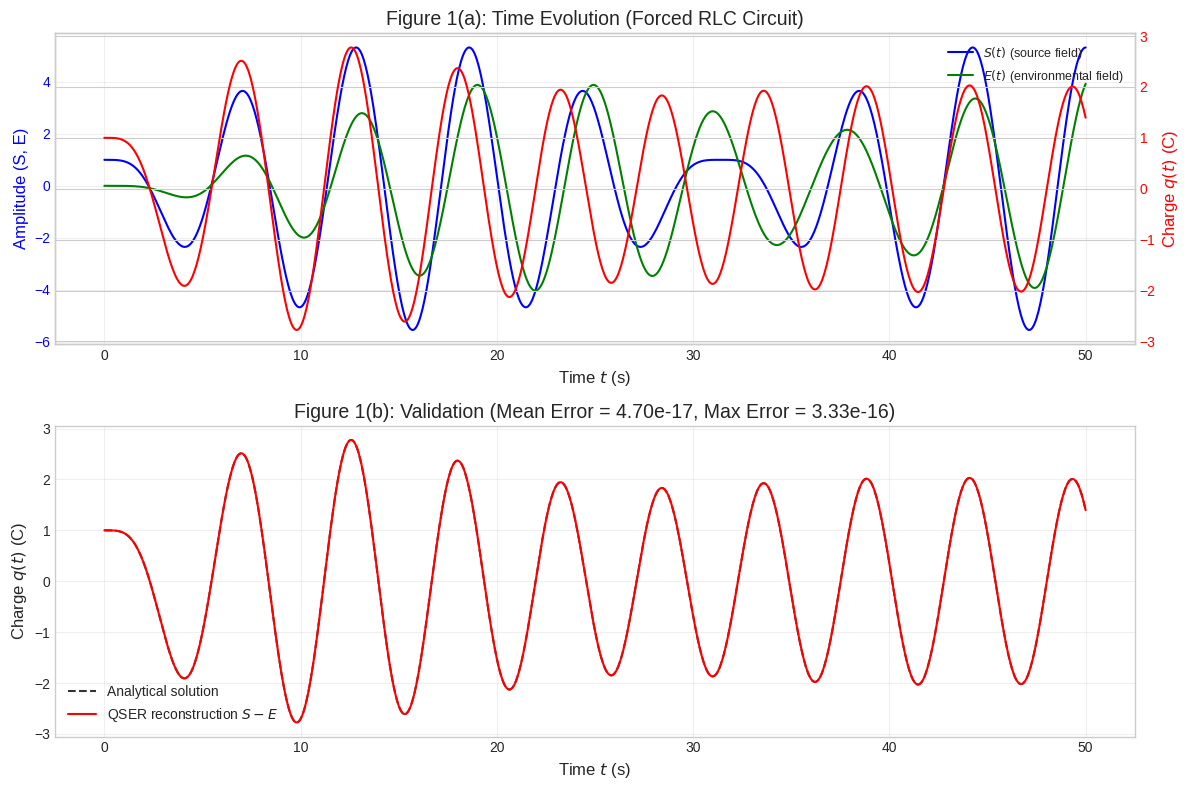

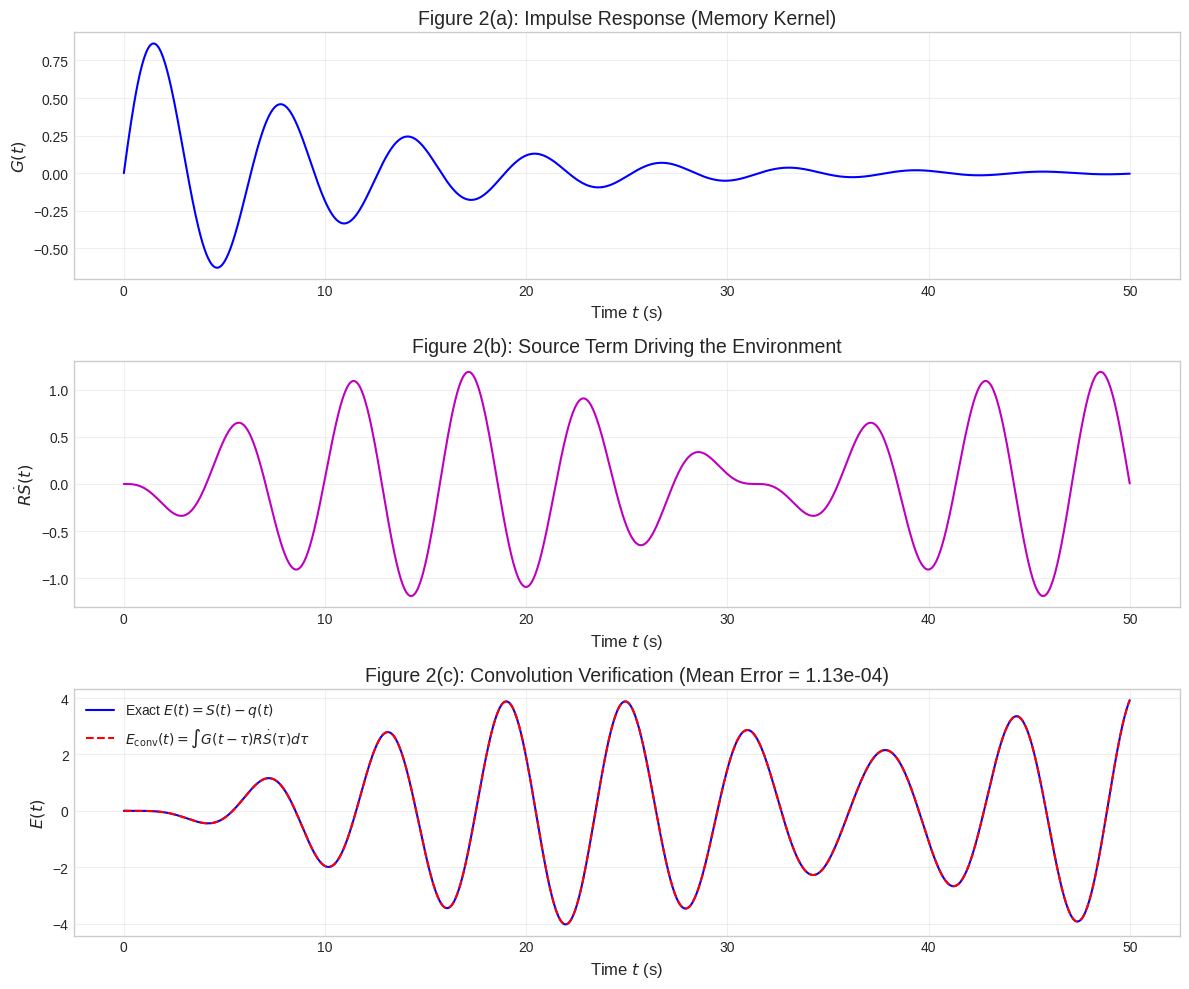

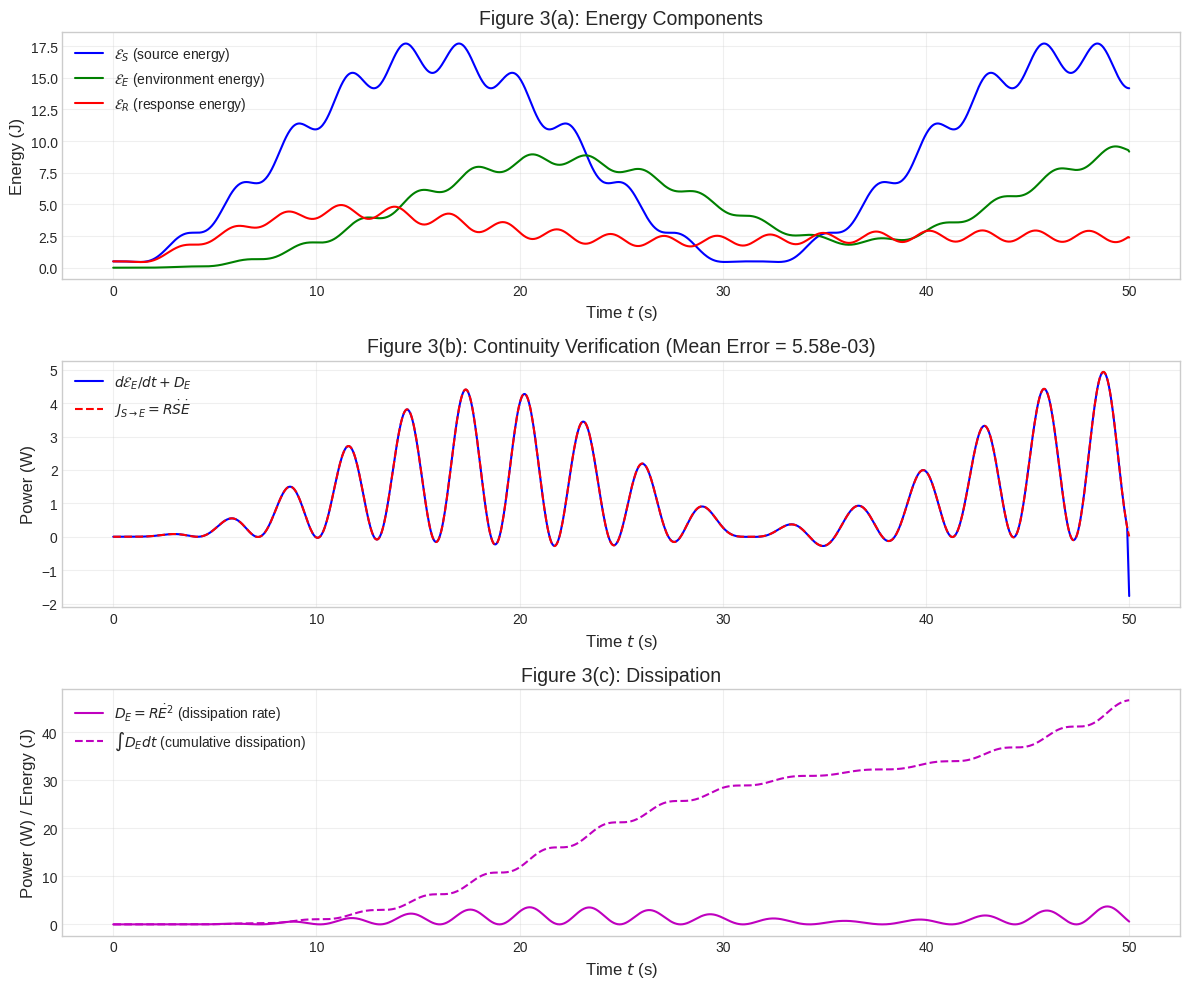

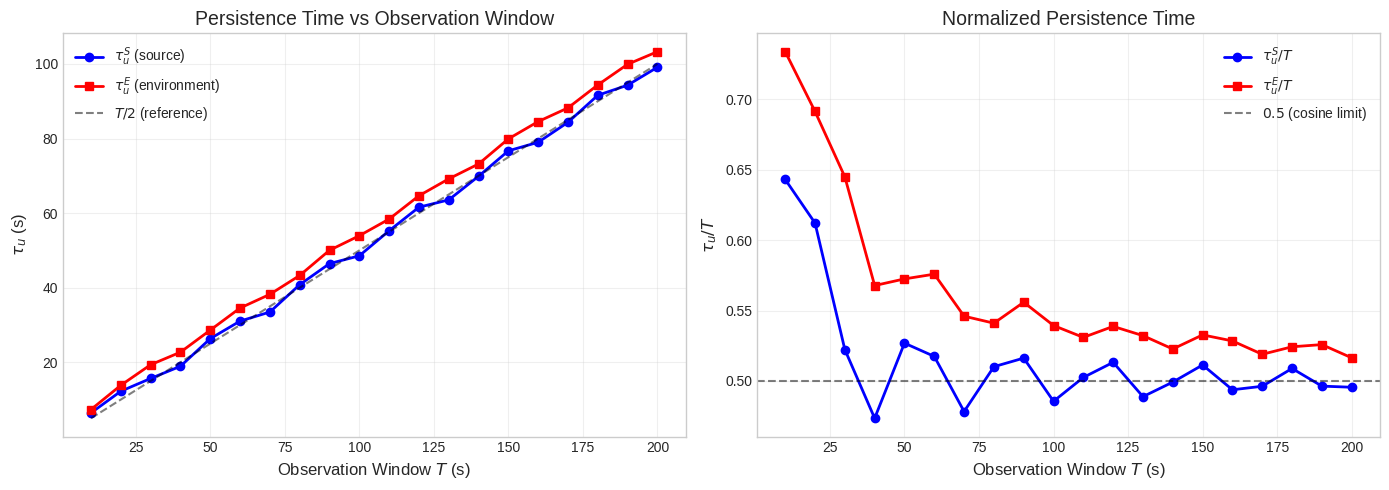

In [50]:
"""
QSER: Forced RLC Circuit - Green's Function Memory Accumulation
Generates S(t), E(t), q(t) analytically and demonstrates memory accumulation via convolution
"""

import numpy as np
import matplotlib.pyplot as plt

# ============================================
# 1. SYSTEM PARAMETERS
# ============================================

L = 1.0          # inductance (H)
C = 1.0          # capacitance (F)
R = 0.2          # resistance (Ω)
q0 = 1.0         # initial charge (C)
i0 = 0.0         # initial current (A)

# Forcing parameters
V0 = 1.0         # amplitude (V)
omega = 1.2      # forcing frequency (rad/s)

# Derived parameters
omega0 = 1.0 / np.sqrt(L * C)           # natural frequency = 1 rad/s
zeta = R / (2 * np.sqrt(L / C))         # damping ratio = 0.1
omega_d = omega0 * np.sqrt(1 - zeta**2) # damped frequency ≈ 0.995 rad/s

# Time settings
T = 50.0          # observation window (s)
N = 1000          # number of points
t = np.linspace(0, T, N)
dt = t[1] - t[0]

print("=" * 70)
print("QSER: Forced RLC Circuit Results")
print("=" * 70)
print(f"Parameters: L={L} H, C={C} F, R={R} Ω")
print(f"Natural frequency ω0 = {omega0:.4f} rad/s")
print(f"Damping ratio ζ = {zeta:.4f}")
print(f"Damped frequency ωd = {omega_d:.4f} rad/s")
print(f"Forcing: v(t) = {V0} cos({omega}t) V")
print(f"Observation window T = {T} s")
print("=" * 70)

# ============================================
# 2. ANALYTICAL SOLUTIONS
# ============================================

# 2.1 Source field S(t) - forced LC circuit
# Homogeneous solution
S_h = q0 * np.cos(omega0 * t) + (i0 / omega0) * np.sin(omega0 * t)

# Particular solution for sinusoidal forcing (ω ≠ ω0)
S_p = V0 / (L * (omega0**2 - omega**2)) * (np.cos(omega * t) - np.cos(omega0 * t))

# Complete source field
S = S_h + S_p

# Derivative of S
dSdt = -omega0 * q0 * np.sin(omega0 * t) + i0 * np.cos(omega0 * t)
dSdt += V0 / (L * (omega0**2 - omega**2)) * (-omega * np.sin(omega * t) + omega0 * np.sin(omega0 * t))

# 2.2 Traditional response q(t) - forced RLC circuit
# Impedance and phase
Z = np.sqrt((1/C - L*omega**2)**2 + (R*omega)**2)
phi = np.arctan2(R*omega, 1/C - L*omega**2)

# Particular solution (steady-state)
q_p = V0 / Z * np.cos(omega * t - phi)

# Homogeneous solution (transient)
# Initial conditions for homogeneous part
q_h0 = q0 - q_p[0]
dq_h0 = i0 - (-V0 / Z * omega * np.sin(-phi))  # derivative at t=0

# Constants for homogeneous solution
A = q_h0
B = (dq_h0 + zeta * omega0 * A) / omega_d

q_h = np.exp(-zeta * omega0 * t) * (A * np.cos(omega_d * t) + B * np.sin(omega_d * t))

# Complete response
q = q_h + q_p

# Derivative of q
dqdt = np.gradient(q, dt)

# 2.3 Environmental field E(t)
E = S - q
dEdt = dSdt - dqdt

# ============================================
# 3. GREEN'S FUNCTION AND CONVOLUTION
# ============================================

# Impulse response (Green's function)
def green_function(t):
    """Impulse response of RLC circuit"""
    return (1/(L * omega_d)) * np.exp(-zeta * omega0 * t) * np.sin(omega_d * t)

G = green_function(t)

# Numerical convolution: E_conv(t) = ∫ G(t-τ) * R * dS/dτ dτ
E_conv = np.zeros(N)
source_term = R * dSdt

for i in range(1, N):
    # Convolution integral using trapezoidal rule
    tau = t[:i+1]
    G_shifted = green_function(t[i] - tau)
    integrand = G_shifted * source_term[:i+1]
    E_conv[i] = np.trapz(integrand, tau)

# ============================================
# 4. ENERGY COMPONENTS
# ============================================

# Source energy (varies due to forcing)
E_S = 0.5 * L * dSdt**2 + 0.5 * (1/C) * S**2

# Environmental energy
E_E = 0.5 * L * dEdt**2 + 0.5 * (1/C) * E**2

# Response energy
E_R = 0.5 * L * (dSdt - dEdt)**2 + 0.5 * (1/C) * (S - E)**2

# Energy flux from source to environment
J_SE = R * dSdt * dEdt

# Dissipation rate within environment
D_E = R * dEdt**2

# Rate of change of environmental energy
dE_E_dt = np.gradient(E_E, dt)

# Cumulative dissipation
cumulative_dissipation = np.cumsum(D_E) * dt

# ============================================
# 5. VALIDATION
# ============================================

# Reconstruction error
reconstruction_error = np.abs(q - (S - E))
max_error = np.max(reconstruction_error)
mean_error = np.mean(reconstruction_error)

# Green's function convolution error
green_error = np.abs(E - E_conv)
max_green_error = np.max(green_error[100:])  # ignore early transients
mean_green_error = np.mean(green_error[100:])

# Energy conservation in S (should follow power balance, not constant)
# We check that the non-conservative part is zero: no dissipation in L_c
# The variation in E_S comes from external forcing, not from internal dissipation

# ============================================
# 6. PERSISTENCE TIMES
# ============================================

def compute_tau_u(t, f):
    """Compute unsigned centroid persistence time"""
    dfdt = np.gradient(f, t[1] - t[0])
    abs_dfdt = np.abs(dfdt)
    numerator = np.trapz(t * abs_dfdt, t)
    denominator = np.trapz(abs_dfdt, t)
    if denominator < 1e-12:
        return np.inf
    return numerator / denominator

tau_S = compute_tau_u(t, S)
tau_E = compute_tau_u(t, E)

# ============================================
# 7. PRINT RESULTS
# ============================================

print("-" * 70)
print(f"Persistence time τ_u^S = {tau_S:.2f} s (scales with T)")
print(f"Persistence time τ_u^E = {tau_E:.2f} s")
print("-" * 70)
print(f"Mean reconstruction error |q - (S-E)| = {mean_error:.2e}")
print(f"Max reconstruction error |q - (S-E)| = {max_error:.2e}")
print(f"Mean Green's function convolution error = {mean_green_error:.2e}")
print(f"Max Green's function convolution error = {max_green_error:.2e}")
print("-" * 70)
print(f"Source energy range: [{np.min(E_S):.4f}, {np.max(E_S):.4f}] J")
print(f"Final environmental energy: {E_E[-1]:.6f} J")
print(f"Final response energy: {E_R[-1]:.6f} J")
print("=" * 70)

# Energy continuity error
continuity_error = np.abs(dE_E_dt + D_E - J_SE)
print(f"Mean continuity error: {np.mean(continuity_error):.2e}")
print(f"Max continuity error: {np.max(continuity_error):.2e}")
print("=" * 70)

# ============================================
# 8. FIGURE 1: Time Evolution (Two Panels)
# ============================================

fig1, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Top Panel: S, E on left axis, q on right axis
ax1.plot(t, S, 'b-', label=r'$S(t)$ (source field)', linewidth=1.5)
ax1.plot(t, E, 'g-', label=r'$E(t)$ (environmental field)', linewidth=1.5)
ax1.set_xlabel('Time $t$ (s)', fontsize=12)
ax1.set_ylabel('Amplitude (S, E)', color='b', fontsize=12)
ax1.tick_params(axis='y', labelcolor='b')
ax1.grid(True, alpha=0.3)

# Twin axis for response
ax1_twin = ax1.twinx()
ax1_twin.plot(t, q, 'r-', label=r'$q(t) = S(t) - E(t)$', linewidth=1.5)
ax1_twin.set_ylabel('Charge $q(t)$ (C)', color='r', fontsize=12)
ax1_twin.tick_params(axis='y', labelcolor='r')

ax1.set_title('Figure 1(a): Time Evolution (Forced RLC Circuit)', fontsize=14)
ax1.legend(loc='upper right', fontsize=9)

# Bottom Panel: Validation
ax2.plot(t, q, 'k--', label='Analytical solution', linewidth=1.5, alpha=0.8)
ax2.plot(t, S - E, 'r-', label='QSER reconstruction $S - E$', linewidth=1.5)
ax2.set_xlabel('Time $t$ (s)', fontsize=12)
ax2.set_ylabel('Charge $q(t)$ (C)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_title(f'Figure 1(b): Validation (Mean Error = {mean_error:.2e}, Max Error = {max_error:.2e})', fontsize=14)

plt.tight_layout()
plt.savefig('rlc_fig1.pdf', bbox_inches='tight')
plt.savefig('rlc_fig1.png', dpi=300, bbox_inches='tight')
print("\n✓ Figure 1 saved: rlc_fig1.pdf/png")

# ============================================
# 9. FIGURE 2: Green's Function and Convolution
# ============================================

fig2, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

# Top Panel: Green's function
ax1.plot(t, G, 'b-', linewidth=1.5)
ax1.set_xlabel('Time $t$ (s)', fontsize=12)
ax1.set_ylabel('$G(t)$', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_title('Figure 2(a): Impulse Response (Memory Kernel)', fontsize=14)

# Middle Panel: Source term R·dS/dt
ax2.plot(t, source_term, 'm-', linewidth=1.5)
ax2.set_xlabel('Time $t$ (s)', fontsize=12)
ax2.set_ylabel('$R\dot{S}(t)$', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_title('Figure 2(b): Source Term Driving the Environment', fontsize=14)

# Bottom Panel: Comparison of exact E and convolution
ax3.plot(t, E, 'b-', label='Exact $E(t) = S(t) - q(t)$', linewidth=1.5)
ax3.plot(t, E_conv, 'r--', label='$E_{\\text{conv}}(t) = \\int G(t-\\tau) R\\dot{S}(\\tau) d\\tau$', linewidth=1.5)
ax3.set_xlabel('Time $t$ (s)', fontsize=12)
ax3.set_ylabel('$E(t)$', fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_title(f'Figure 2(c): Convolution Verification (Mean Error = {mean_green_error:.2e})', fontsize=14)

plt.tight_layout()
plt.savefig('rlc_fig2.pdf', bbox_inches='tight')
plt.savefig('rlc_fig2.png', dpi=300, bbox_inches='tight')
print("✓ Figure 2 saved: rlc_fig2.pdf/png")

# ============================================
# 10. FIGURE 3: Energy Components and Continuity
# ============================================

fig3, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

# Top Panel: Energy components
ax1.plot(t, E_S, 'b-', label=r'$\mathcal{E}_S$ (source energy)', linewidth=1.5)
ax1.plot(t, E_E, 'g-', label=r'$\mathcal{E}_E$ (environment energy)', linewidth=1.5)
ax1.plot(t, E_R, 'r-', label=r'$\mathcal{E}_R$ (response energy)', linewidth=1.5)
ax1.set_xlabel('Time $t$ (s)', fontsize=12)
ax1.set_ylabel('Energy (J)', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_title('Figure 3(a): Energy Components', fontsize=14)

# Middle Panel: Continuity verification
ax2.plot(t, dE_E_dt + D_E, 'b-', label=r'$d\mathcal{E}_E/dt + D_E$', linewidth=1.5)
ax2.plot(t, J_SE, 'r--', label=r'$J_{S\to E} = R\dot{S}\dot{E}$', linewidth=1.5)
ax2.set_xlabel('Time $t$ (s)', fontsize=12)
ax2.set_ylabel('Power (W)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_title(f'Figure 3(b): Continuity Verification (Mean Error = {np.mean(continuity_error):.2e})', fontsize=14)

# Bottom Panel: Dissipation
ax3.plot(t, D_E, 'm-', label=r'$D_E = R\dot{E}^2$ (dissipation rate)', linewidth=1.5)
ax3.plot(t, cumulative_dissipation, 'm--', label=r'$\int D_E dt$ (cumulative dissipation)', linewidth=1.5)
ax3.set_xlabel('Time $t$ (s)', fontsize=12)
ax3.set_ylabel('Power (W) / Energy (J)', fontsize=12)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_title('Figure 3(c): Dissipation', fontsize=14)

plt.tight_layout()
plt.savefig('rlc_fig3.pdf', bbox_inches='tight')
plt.savefig('rlc_fig3.png', dpi=300, bbox_inches='tight')
print("✓ Figure 3 saved: rlc_fig3.pdf/png")

# ============================================
# 11. FIGURE 4: Persistence Time Scaling
# ============================================

# Compute scaling over different window lengths
T_values = np.arange(10, 210, 10)
N_scaling = 1000
tau_S_values = []
tau_E_values = []

for T_scaling in T_values:
    t_scaling = np.linspace(0, T_scaling, N_scaling)
    dt_scaling = t_scaling[1] - t_scaling[0]
    
    # Recompute S and E for this window
    S_h_scaling = q0 * np.cos(omega0 * t_scaling) + (i0 / omega0) * np.sin(omega0 * t_scaling)
    S_p_scaling = V0 / (L * (omega0**2 - omega**2)) * (np.cos(omega * t_scaling) - np.cos(omega0 * t_scaling))
    S_scaling = S_h_scaling + S_p_scaling
    
    # Response
    q_p_scaling = V0 / Z * np.cos(omega * t_scaling - phi)
    q_h_scaling = np.exp(-zeta * omega0 * t_scaling) * (A * np.cos(omega_d * t_scaling) + B * np.sin(omega_d * t_scaling))
    q_scaling = q_h_scaling + q_p_scaling
    
    E_scaling = S_scaling - q_scaling
    
    tau_S_values.append(compute_tau_u(t_scaling, S_scaling))
    tau_E_values.append(compute_tau_u(t_scaling, E_scaling))

tau_S_values = np.array(tau_S_values)
tau_E_values = np.array(tau_E_values)

fig4, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: τ_u vs T
ax1.plot(T_values, tau_S_values, 'bo-', label=r'$\tau_u^S$ (source)', linewidth=2, markersize=6)
ax1.plot(T_values, tau_E_values, 'rs-', label=r'$\tau_u^E$ (environment)', linewidth=2, markersize=6)
ax1.plot(T_values, T_values/2, 'k--', label=r'$T/2$ (reference)', alpha=0.5)
ax1.set_xlabel('Observation Window $T$ (s)', fontsize=12)
ax1.set_ylabel(r'$\tau_u$ (s)', fontsize=12)
ax1.set_title('Persistence Time vs Observation Window', fontsize=14)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right: τ_u/T ratio
ax2.plot(T_values, tau_S_values / T_values, 'bo-', label=r'$\tau_u^S / T$', linewidth=2, markersize=6)
ax2.plot(T_values, tau_E_values / T_values, 'rs-', label=r'$\tau_u^E / T$', linewidth=2, markersize=6)
ax2.axhline(y=0.5, color='k', linestyle='--', alpha=0.5, label=r'$0.5$ (cosine limit)')
ax2.set_xlabel('Observation Window $T$ (s)', fontsize=12)
ax2.set_ylabel(r'$\tau_u / T$', fontsize=12)
ax2.set_title('Normalized Persistence Time', fontsize=14)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('rlc_fig4.pdf', bbox_inches='tight')
plt.savefig('rlc_fig4.png', dpi=300, bbox_inches='tight')
print("✓ Figure 4 saved: rlc_fig4.pdf/png")

# ============================================
# 12. ADDITIONAL VALIDATION: Energy Relationship
# ============================================

E_coupling = L * dSdt * dEdt + (1/C) * S * E
E_R_from_relation = E_S + E_E - E_coupling
relation_error = np.max(np.abs(E_R - E_R_from_relation))

print("\n" + "=" * 70)
print("Energy Relationship Verification")
print("=" * 70)
print(f"Verifying: ℰ_R = ℰ_S + ℰ_E - ℰ_coupling")
print(f"Maximum error: {relation_error:.2e}")
print("=" * 70)

plt.show()

In [1]:
pwd

'/home/ahmad/Yandex.Disk/Python 2026/Qtheory_library/QSER conference paper/cmes van der pol paper'